In [2]:
import numpy as np
from scipy.stats import norm, expon
from iminuit import Minuit, cost

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
n_norm = 500
n_expon = 1000

mu = 10
scale_norm = 3
scale_expon = 0.75
rate = 1 / scale_expon
rv_norm = norm.rvs(loc=10, scale=3, size=n_norm)
rv_expon = expon.rvs(scale=scale_expon, size=n_expon)

rv = np.concatenate([rv_norm, rv_expon])
rv = np.array(list(filter(lambda x: x > 0, rv)))

print(mu, scale_norm)
print(scale_expon, rate)

10 3
0.75 1.3333333333333333


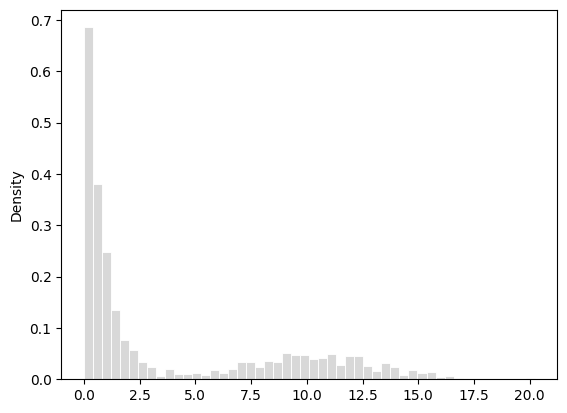

In [4]:
sns.histplot(rv, bins=50, stat="density",
             color="0.8", edgecolor="white", label="data")
plt.show()

In [5]:
def pdf(x, f, rate, mu, sigma):
    acc = 1.0 - norm.cdf(0.0, mu, sigma)
    g = norm.pdf(x, mu, sigma) / acc
    e = expon.pdf(x, scale=1.0 / rate)
    return f * g + (1.0 - f) * e

In [6]:
m = Minuit(nll := cost.UnbinnedNLL(rv, pdf),
           f=0.5, rate=1.0, mu=np.median(rv), sigma=np.std(rv))
m.limits["f"] = (0, 1)
m.limits["rate"] = (1e-6, None)
m.limits["sigma"] = (1e-6, None)
m.migrad()
m.hesse()

print(m.valid)
for p in m.parameters:
    print(f"{p:6s} = {m.values[p]:.4f} ± {m.errors[p]:.4f}")

True
f      = 0.3276 ± 0.0126
rate   = 1.2612 ± 0.0463
mu     = 10.2174 ± 0.1456
sigma  = 2.8674 ± 0.1140


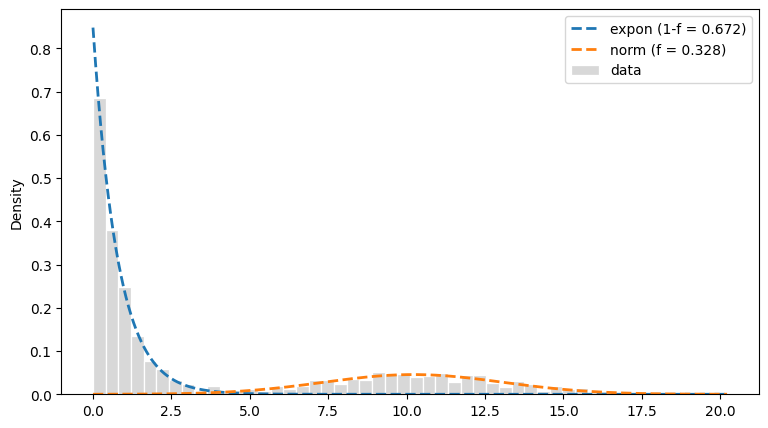

In [7]:
v = m.values
x = np.linspace(0, rv.max(), 1000)

acc = 1.0 - norm.cdf(0.0, v["mu"], v["sigma"])
comp_g = v["f"] * norm.pdf(x, v["mu"], v["sigma"]) / acc
comp_e = (1 - v["f"]) * expon.pdf(x, scale=1 / v["rate"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(rv, bins=50, stat="density", ax=ax,
             color="0.8", edgecolor="white", label="data")
ax.plot(x, comp_e, "--", lw=2, label=f"expon (1-f = {1-v['f']:.3f})")
ax.plot(x, comp_g, "--", lw=2, label=f"norm (f = {v['f']:.3f})")
ax.legend()
plt.show()